<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/notebooks/Lab-6%20Transfer%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Exercise-6
### Implement transfer learning to classify six kinds of surface defects of the hot-rolled steel strip using ResNet50, Google Inception Net & EfficientNet.

#### Problem Description:

<div align="justify">


Six types of typical surface defects in hot-rolled steel strips are considered: rolled-in scale (RS), patches (Pa), crazing (Cr), pitted surface (PS), inclusion (In), and scratches (Sc). The dataset contains 1,800 grayscale images, with 300 samples for each defect type. Each class is divided into 240 training images and 60 testing images. The objective is to classify the defects using transfer learning with ResNet50, InceptionNet, and EfficientNet.

Dataset: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database  

</div>

### Setup

In [19]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os

In [20]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# Data Download and Path Setup
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

train_dir = os.path.join(path, "NEU-DET", "train", "images")
test_dir = os.path.join(path, "NEU-DET", "validation", "images")

print(f"Checking Path: {train_dir}")
if os.path.exists(train_dir):
    print("✅ Success: Image folders located!")
else:
    print("❌ Error: Path still not found. Check the directory structure.")

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Checking Path: /kaggle/input/neu-surface-defect-database/NEU-DET/train/images
✅ Success: Image folders located!


In [8]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
AUTOTUNE = tf.data.AUTOTUNE

# Data Loading
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False # Keep false for accurate Confusion Matrix
)

class_names = train_ds.class_names
print(f"Classes identified: {class_names}")

# Optimization for performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.
Classes identified: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


### Visualize Sample Images

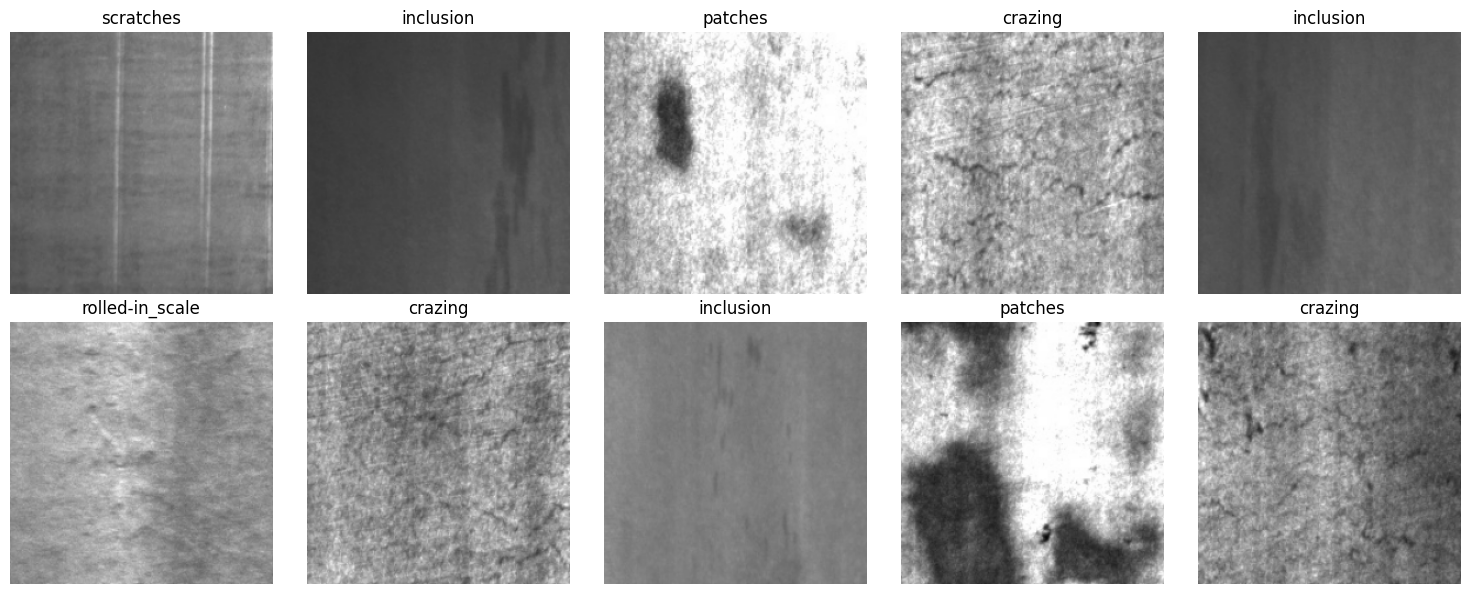

In [10]:
# Grab one batch (32 images) from the dataset
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 6))

    # Plot the first 10 images from that batch
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)

        # Cast to uint8 for plotting if images are floats
        plt.imshow(images[i].numpy().astype("uint8"))

        # Look up the class name using the label index
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Data Augmentation

In [11]:
# Data Augmentation
# Helps prevent overfitting on small datasets (1,800 images total)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

### Build Transfer Learning Model

In [12]:
def build_model(model_name):
    inputs = keras.Input(shape=(224, 224, 3))

    # 1. Apply Augmentation
    x = data_augmentation(inputs)

    # 2. Select Base Model & Preprocessing
    if model_name == "ResNet50":
        x = keras.applications.resnet50.preprocess_input(x)
        base = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

    elif model_name == "InceptionV3":
        x = keras.applications.inception_v3.preprocess_input(x)
        base = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

    elif model_name == "EfficientNetB0":
        # EfficientNet has internal rescaling; no preprocess_input needed
        base = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

    # Freeze base model
    base.trainable = False

    # 3. Build Top Head
    # training=False ensures BatchNormalization layers run in inference mode
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(6, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
# Callbacks
callbacks = [
    # Stop if validation loss doesn't improve for 3 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    # Lower learning rate if progress stalls
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),

    # Save the best model to a file
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

### Model Training and Evaluation

In [14]:
model_names = ["ResNet50", "InceptionV3", "EfficientNetB0"]
histories = {}
best_acc = 0.0
best_model_name = ""

for name in model_names:
    print(f"\n--- Training {name} ---")
    model = build_model(name)

    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    histories[name] = history

    # Evaluate accuracy
    _, acc = model.evaluate(test_ds, verbose=0)
    print(f"Final {name} Test Accuracy: {acc:.4f}")

    # Pick the best model
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        model.save("best_defect_model.keras")

print(f"\nThe best performing model is {best_model_name} with {best_acc:.4f} accuracy!")


--- Training ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.9181 - loss: 0.2525 - val_accuracy: 0.9500 - val_loss: 0.1471 - learning_rate: 0.0010
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.9924 - loss: 0.0314 - val_accuracy: 0.9722 - val_loss: 0.0901 - learning_rate: 0.0010
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.9944 - loss: 0.0254 - val_accuracy: 0.9806 - val_loss: 0.0652 - learning_rate: 0.0010
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.9882 - loss: 0.0358 - val_accuracy: 0.9917 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9951 - loss: 0.0144 - val_accuracy: 0.9861 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - accuracy: 0.9924 - loss: 0.0201 - val_accuracy: 0.9944 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 7/2

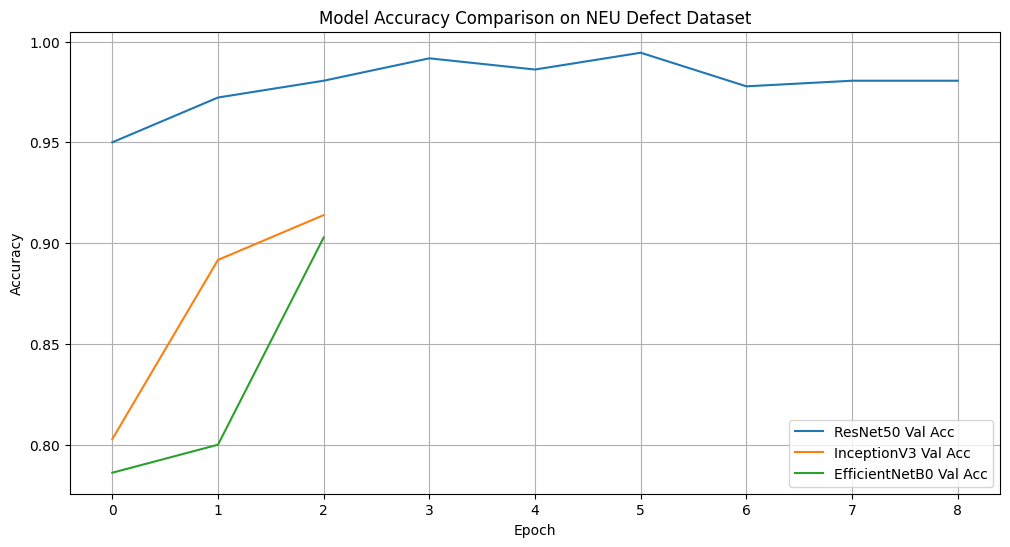

In [15]:
# Plot Comparison
plt.figure(figsize=(12, 6))

for name in model_names:
    plt.plot(histories[name].history['val_accuracy'], label=f'{name} Val Acc')

plt.title('Model Accuracy Comparison on NEU Defect Dataset')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Evaluating the best model
best_model = keras.models.load_model("best_defect_model.keras")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step



Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.98      0.99        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      0.98      0.99        60
rolled-in_scale       0.98      1.00      0.99        60
      scratches       0.98      1.00      0.99        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



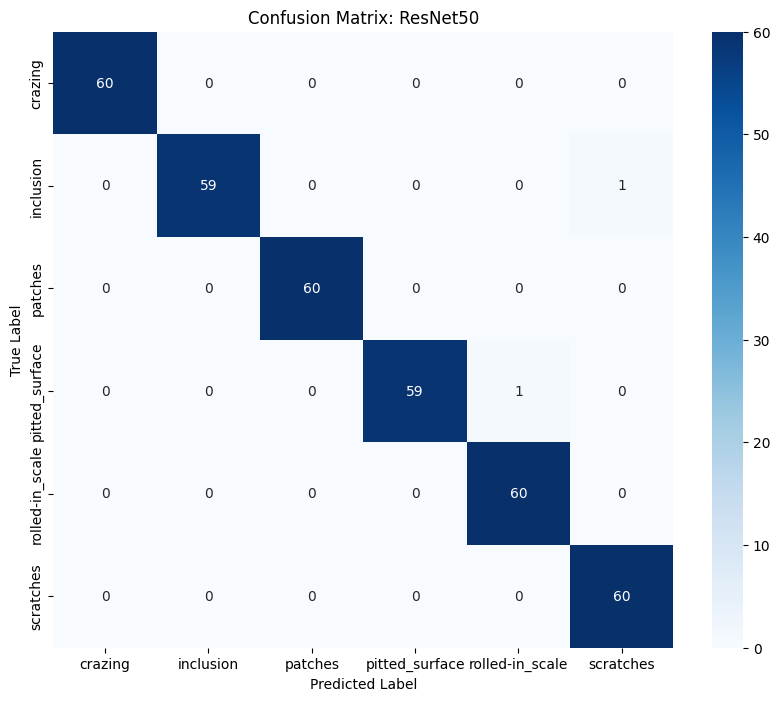

In [21]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Visualize Predictions

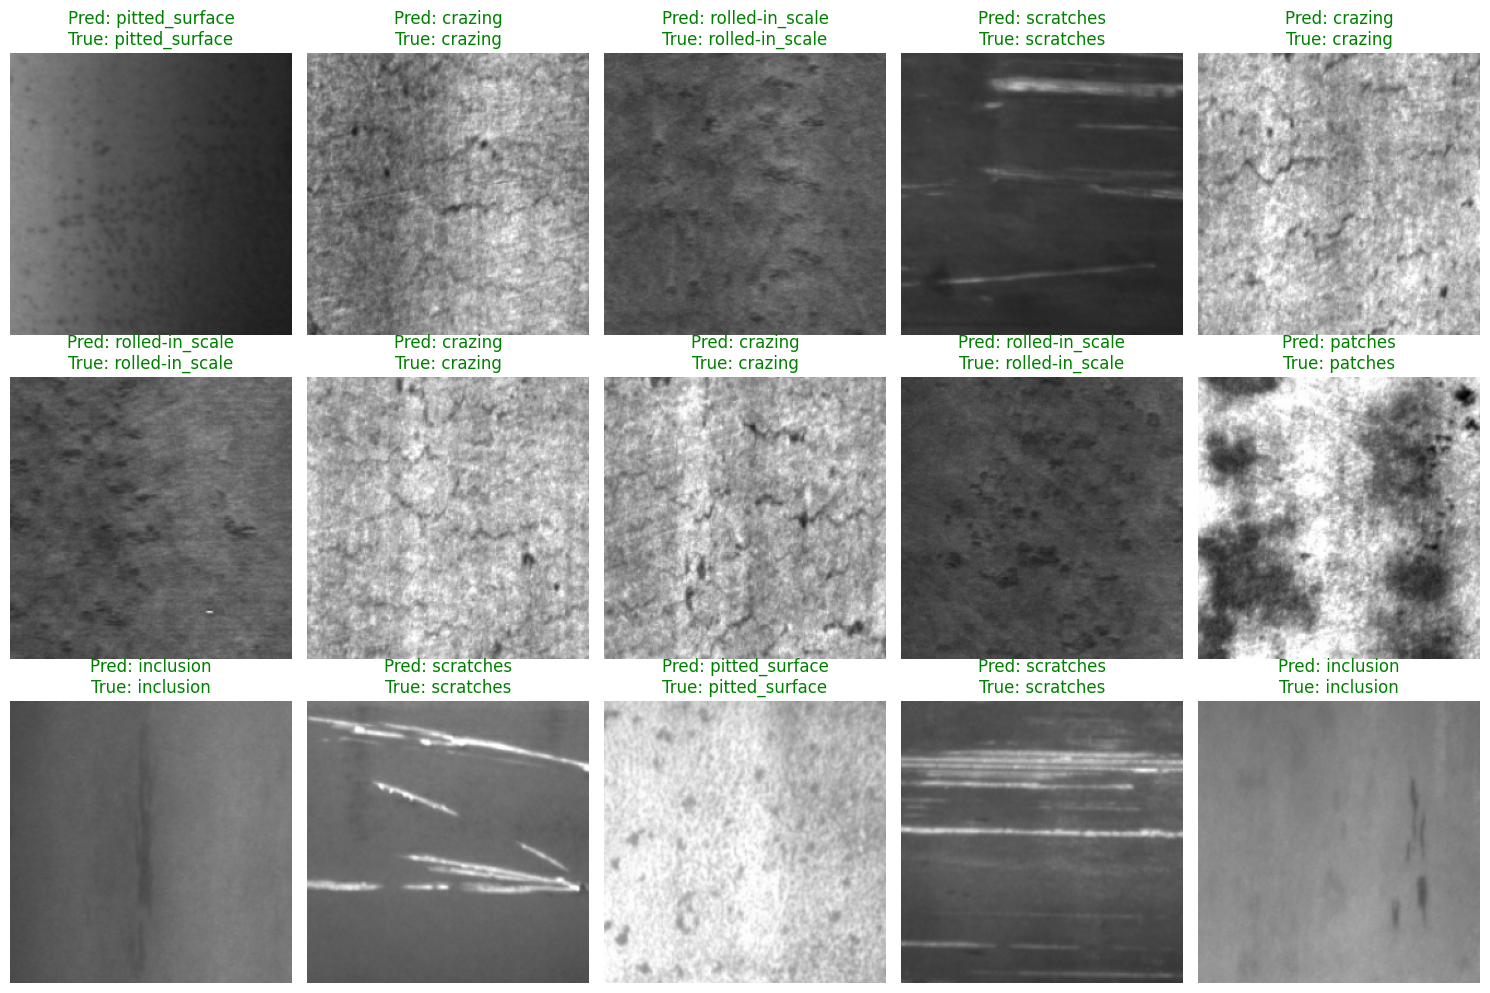

In [23]:
plt.figure(figsize=(15, 10))

# Collect all images and labels from the test dataset
all_imgs = []
all_lbls = []
for imgs, lbls in test_ds:
    all_imgs.append(imgs.numpy())
    all_lbls.append(lbls.numpy())

all_imgs = np.concatenate(all_imgs, axis=0)
all_lbls = np.concatenate(all_lbls, axis=0)

# Pick 15 random indices from the entire set
indices = np.random.choice(len(all_imgs), 15, replace=False)

# Predict on these specific 15 images
preds = best_model.predict(all_imgs[indices], verbose=0)

for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(all_imgs[idx].astype("uint8"))

    p_idx = np.argmax(preds[i])
    a_idx = all_lbls[idx]

    color = 'green' if p_idx == a_idx else 'red'
    plt.title(f"Pred: {class_names[p_idx]}\nTrue: {class_names[a_idx]}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()